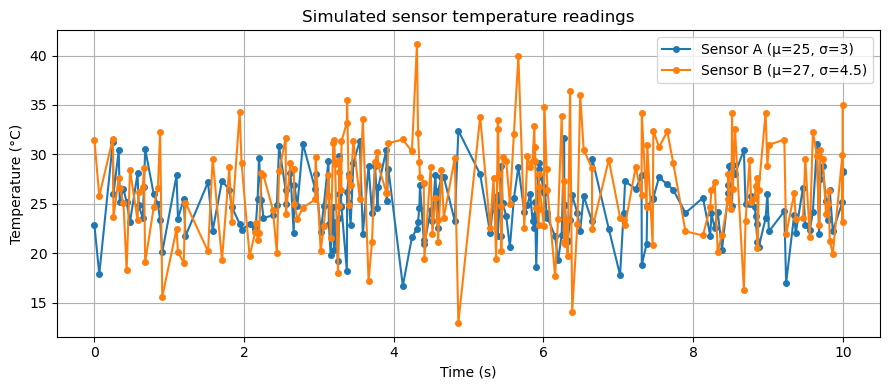

In [16]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.
import numpy as np
import matplotlib.pyplot as plt

seed = 7336
rng = np.random.default_rng(seed)

n = 200
t = rng.uniform(0.0, 10.0, size=n) # 200 timestamps uniformly in [0,10)
order = np.argsort(t) # sort for a proper time-series plot
t = t[order]
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)[order]
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)[order]

plt.figure(figsize=(9,4))
plt.plot(t, sensor_a, '-o', markersize=4, label='Sensor A (μ=25, σ=3)')
plt.plot(t, sensor_b, '-o', markersize=4, label='Sensor B (μ=27, σ=4.5)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Simulated sensor temperature readings')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

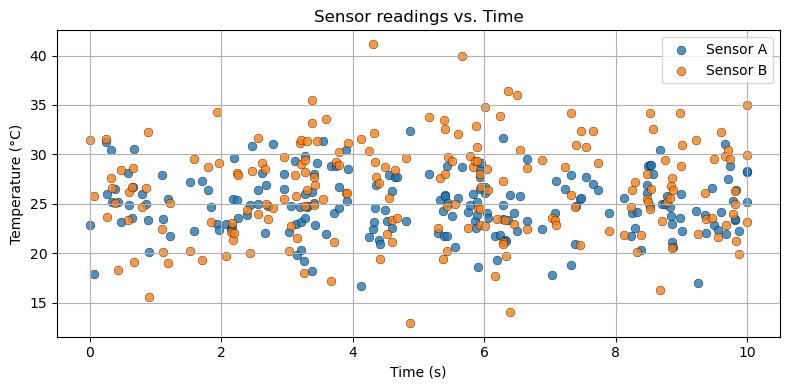

In [17]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.
time = globals().get('timestamps', globals().get('t')) # prefer timestamps, fall back to t

plt.figure(figsize=(8,4))
plt.scatter(time, sensor_a, c='C0', label='Sensor A', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
plt.scatter(time, sensor_b, c='C1', label='Sensor B', s=40, alpha=0.8, edgecolors='k', linewidth=0.3)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor readings vs. Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

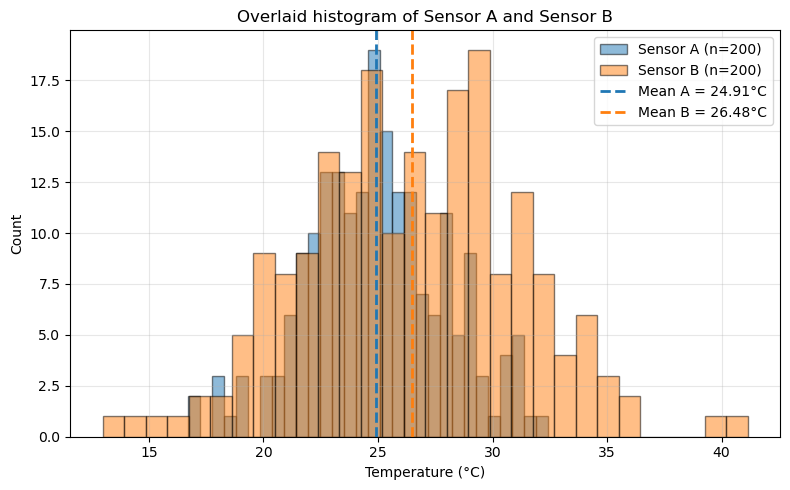

In [18]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

import matplotlib.pyplot as plt
import numpy as np
bins = 30
mean_a = float(sensor_a.mean())
mean_b = float(sensor_b.mean())
plt.figure(figsize=(8, 5))
plt.hist(sensor_a, bins=bins, alpha=0.5, label=f"Sensor A (n={sensor_a.size})", color="C0", edgecolor="k")
plt.hist(sensor_b, bins=bins, alpha=0.5, label=f"Sensor B (n={sensor_b.size})", color="C1", edgecolor="k")
plt.axvline(mean_a, color="C0", linestyle="--", linewidth=2, label=f"Mean A = {mean_a:.2f}°C")
plt.axvline(mean_b, color="C1", linestyle="--", linewidth=2, label=f"Mean B = {mean_b:.2f}°C")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.title("Overlaid histogram of Sensor A and Sensor B")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\farza\AppData\Local\Temp\ipykernel_34608\1157624029.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([a, b],


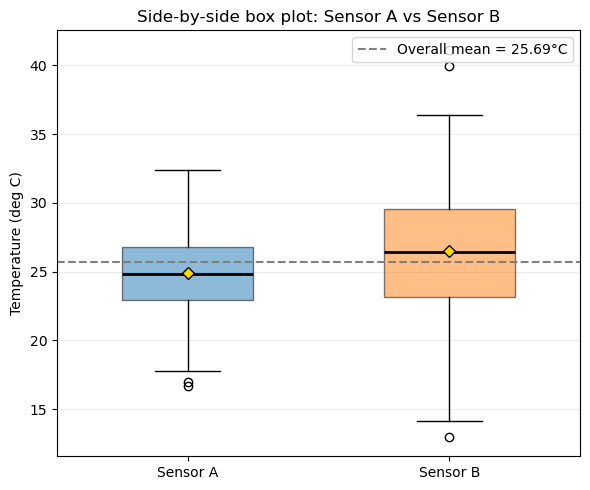

In [19]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

import matplotlib.pyplot as plt
import numpy as np

#ensure 1D arrays
a = np.asarray(sensor_a).ravel()
b = np.asarray(sensor_b).ravel()

combined = np.concatenate([a, b])
overall_mean = float(np.mean(combined))

fig, ax = plt.subplots(figsize=(6,5))
bp = ax.boxplot([a, b],
labels=['Sensor A', 'Sensor B'],
notch=False,
patch_artist=True,
showmeans=True,
widths=0.5,
vert=True)

#style
colors = ['C0', 'C1']
for box, color in zip(bp['boxes'], colors):
 box.set(facecolor=color, alpha=0.5, edgecolor='k')
for median in bp['medians']:
 median.set(color='k', linewidth=2)
if 'means' in bp:
 for mean in bp['means']:
   mean.set(marker='D', markeredgecolor='k', markerfacecolor='gold')

#overall mean line and annotation
ax.axhline(overall_mean, color='gray', linestyle='--', linewidth=1.5, label=f'Overall mean = {overall_mean:.2f}°C')
ax.legend(loc='upper right')

ax.set_ylabel('Temperature (deg C)')
ax.set_title('Side-by-side box plot: Sensor A vs Sensor B')
ax.grid(axis='y', alpha=0.25)

#sensible y-limits with padding
ymin, ymax = combined.min(), combined.max()
pad = max(1.0, 0.05*(ymax - ymin))
ax.set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()